# Notes

Perform logistic regression at residue level but only focus on entangled proteins.

This notebook analysis control the SASA as the confounder. 
Reason:

change in entanglement -> change in SASA
change in SASA -> change in proteolytic susceptibility.

Therefore, SASA is a mediator, not confounder. To estimate the total effect of entangled region on proteolytic susceptibility, we should not include the SASA as the confounder.

In [1]:
import sys
from datetime import datetime

import pandas as pd
import numpy as np
import scipy as sp
import scipy.stats as ss

import statsmodels as sm
from statsmodels.stats.contingency_tables import Table2x2
import statsmodels.formula.api as smf

import matplotlib as mpl
import matplotlib.pyplot as plt

from utils import *

In [2]:
# Date running analysis
RUN_START = datetime.now().astimezone()

print("=" * 50)
print("RUN START")
print("=" * 50)
print(f"{'date':12s}: {RUN_START.strftime('%Y-%m-%d')}")
print(f"{'time':12s}: {RUN_START.strftime('%H:%M:%S %Z')}")
print(f"{'iso':12s}: {RUN_START.isoformat()}")
print("=" * 50)


# Logging: software version
versions = {
    "python": sys.version.replace("\n", " "),
    "pandas": get_version(pd, "pandas"),
    "numpy": get_version(np, "numpy"),
    "scipy": get_version(sp, "scipy"),
    "matplotlib": get_version(mpl, "matplotlib"),
    "statsmodels": get_version(sm, "statsmodels"),
}

# Pretty print
print("Software versions:\n")
for k, v in versions.items():
    print(f"{k:12s}: {v}")

RUN START
date        : 2026-03-31
time        : 14:02:10 +07
iso         : 2026-03-31T14:02:10.523449+07:00
Software versions:

python      : 3.13.12 | packaged by conda-forge | (main, Feb  5 2026, 05:58:33) [Clang 19.1.7 ]
pandas      : 2.3.3
numpy       : 2.4.2
scipy       : 1.17.0
matplotlib  : 3.10.8
statsmodels : 0.14.6


In [3]:
# load custom setting for figures
set_nature_style()

In [4]:
# Logging: checksum input files
input_data = ['../data/SC_Ent.pkl']
df_files = pd.DataFrame([
    file_info(f) for f in input_data
])

with pd.option_context("display.max_colwidth", None):
    display(df_files)

,path,size_bytes,sha256
0,../data/SC_Ent.pkl,1640408,fbb3e5435702b31ecd2576fedc14e564b0b50baf85c0a5643db92f6a86f10153


# Load data

In [5]:
df_all = pd.read_pickle('../data/SC_Ent.pkl')
# Only select entangled proteins
df = df_all[df_all['entangled']==1]
df

,SGDID,Uniprot,SC,length_AF,entangled,asphericity,fraction_idp,Knot,cov_lasso,entangled_residues,Cutsite_residues,clustered_entangled_residues
0,S000002468,Q12298,0,539,1,0.139968,0.011132,0,0,"[26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 4...",[],"[27, 31, 34, 35, 36, 38, 39, 40, 41, 42, 43, 4..."
1,S000000094,P35842,0,467,1,0.097823,0.051392,0,0,"[21, 23, 30, 31, 32, 33, 34, 35, 37, 38, 41, 4...",[],"[32, 33, 34, 35, 37, 38, 41, 46, 47, 67, 68, 6..."
2,S000002490,P38961,0,392,1,0.108081,0.295918,0,0,"[177, 178, 179, 180, 181, 182, 183, 184, 190, ...",[],"[181, 193, 266, 267, 268, 290, 292, 293, 294, ..."
3,S000003653,P46956,0,311,1,0.311604,0.099678,0,0,"[64, 65, 68, 69, 70, 71, 72, 73, 74, 75, 78, 1...",[],"[203, 210, 211, 212, 213, 252, 253, 254, 255, ..."
5,S000003242,P53204,0,395,1,0.102152,0.293671,0,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17...",[],"[1, 2, 3, 4, 5, 6, 7, 8, 9, 15, 16, 17, 18, 19..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2249,S000004850,Q05029,0,724,1,0.111921,0.084254,0,0,"[5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 18, 19, 23...",[],"[6, 7, 8, 9, 10, 11, 12, 15, 35, 37, 38, 39, 4..."
2250,S000005337,P53743,0,316,1,0.212209,0.506329,0,0,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",[],"[103, 104, 105, 106, 107, 108, 109, 110, 111, ..."
2251,S000001943,P43619,0,295,1,0.383145,0.071186,0,0,"[1, 2, 3, 4, 5, 8, 10, 12, 13, 14, 15, 16, 17,...",[],"[15, 18, 19, 20, 21, 22, 23, 24, 25, 26, 48, 4..."
2254,S000005185,P11412,1,505,1,0.142002,0.017822,0,0,"[6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...","[394, 395, 396, 397, 398, 399, 400, 401, 402]","[10, 11, 12, 13, 14, 15, 16, 17, 18, 23, 24, 2..."


In [6]:
# Standardize 'length_AF' using z-score
df = df.copy()
df['length_z'] = (df['length_AF'] - df['length_AF'].mean()) / df['length_AF'].std()
df

,SGDID,Uniprot,SC,length_AF,entangled,asphericity,fraction_idp,Knot,cov_lasso,entangled_residues,Cutsite_residues,clustered_entangled_residues,length_z
0,S000002468,Q12298,0,539,1,0.139968,0.011132,0,0,"[26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 4...",[],"[27, 31, 34, 35, 36, 38, 39, 40, 41, 42, 43, 4...",0.002089
1,S000000094,P35842,0,467,1,0.097823,0.051392,0,0,"[21, 23, 30, 31, 32, 33, 34, 35, 37, 38, 41, 4...",[],"[32, 33, 34, 35, 37, 38, 41, 46, 47, 67, 68, 6...",-0.199317
2,S000002490,P38961,0,392,1,0.108081,0.295918,0,0,"[177, 178, 179, 180, 181, 182, 183, 184, 190, ...",[],"[181, 193, 266, 267, 268, 290, 292, 293, 294, ...",-0.409115
3,S000003653,P46956,0,311,1,0.311604,0.099678,0,0,"[64, 65, 68, 69, 70, 71, 72, 73, 74, 75, 78, 1...",[],"[203, 210, 211, 212, 213, 252, 253, 254, 255, ...",-0.635697
5,S000003242,P53204,0,395,1,0.102152,0.293671,0,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17...",[],"[1, 2, 3, 4, 5, 6, 7, 8, 9, 15, 16, 17, 18, 19...",-0.400723
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2249,S000004850,Q05029,0,724,1,0.111921,0.084254,0,0,"[5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 18, 19, 23...",[],"[6, 7, 8, 9, 10, 11, 12, 15, 35, 37, 38, 39, 4...",0.519590
2250,S000005337,P53743,0,316,1,0.212209,0.506329,0,0,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",[],"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",-0.621710
2251,S000001943,P43619,0,295,1,0.383145,0.071186,0,0,"[1, 2, 3, 4, 5, 8, 10, 12, 13, 14, 15, 16, 17,...",[],"[15, 18, 19, 20, 21, 22, 23, 24, 25, 26, 48, 4...",-0.680454
2254,S000005185,P11412,1,505,1,0.142002,0.017822,0,0,"[6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...","[394, 395, 396, 397, 398, 399, 400, 401, 402]","[10, 11, 12, 13, 14, 15, 16, 17, 18, 23, 24, 2...",-0.093020


In [7]:
records = []
for _, row in df.iterrows():
    uniprot = row['Uniprot']
    length = row['length_AF']
    length_z = row['length_z']
    entangled = set(row['clustered_entangled_residues'])
    cutsites = set(row['Cutsite_residues'])
    # sasa_values = row['sasa_per_residue']

    for i in range(1, length+1):
        res_id = f"{uniprot}_{i}"
        is_entangled = int(i in entangled)
        is_cutsite = int(i in cutsites)
        length_z = length_z
        # sasa = sasa_values[i-1]
        
        records.append({
            'Uniprot_ResID': res_id,
            'is_entangled': is_entangled,
            'is_cutsite': is_cutsite,
            'length_z': length_z
        })

In [8]:
df_residue_level = pd.DataFrame(records)
df_residue_level

,Uniprot_ResID,is_entangled,is_cutsite,length_z
0,Q12298_1,0,0,0.002089
1,Q12298_2,0,0,0.002089
2,Q12298_3,0,0,0.002089
3,Q12298_4,0,0,0.002089
4,Q12298_5,0,0,0.002089
...,...,...,...,...
907490,P41819_314,0,0,-0.616116
907491,P41819_315,0,0,-0.616116
907492,P41819_316,0,0,-0.616116
907493,P41819_317,0,0,-0.616116


# Get OR using contingency table

is_cutsite       SC = Yes  SC = No
is_entangled                      
Entangled = Yes      2027   203837
Entangled = No       4277   697354
Crude Odds Ratio: 1.621
95% CI: [1.538, 1.710]
Fisher exact P-value: 5.6298422012642095e-67
--------------------------------------------------


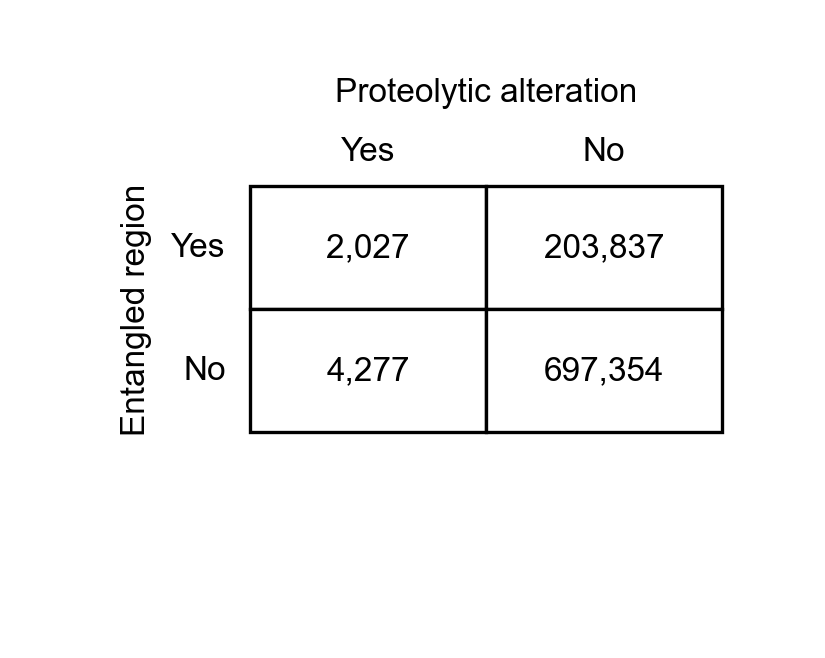

In [9]:
# build contingency table: Yes first, then No
contingency = (
    pd.crosstab(
        df_residue_level["is_entangled"],
        df_residue_level["is_cutsite"]
    )
    .reindex(index=[1, 0], columns=[1, 0])   # <-- this enforces Yes first
    .rename(
        index={1: "Entangled = Yes", 0: "Entangled = No"},
        columns={1: "SC = Yes", 0: "SC = No"},
    )
)
print(contingency)
# convert to numpy array in [[a,b],[c,d]] format
table = contingency.to_numpy()

ct = Table2x2(table)

odds_ratio, pvalue = ss.fisher_exact(table)
ci_low, ci_high = ct.oddsratio_confint(alpha=0.05, method="exact")
print(f"Crude Odds Ratio: {odds_ratio:.3f}")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Fisher exact P-value: {pvalue}")
print('-'*50)

fig, ax = draw_contingency_table(
    table,
    title_top =  "Proteolytic alteration",
    title_left = "Entangled region"
)
fig.savefig('figs/Residue_Level_contingency_table.pdf')
fig.savefig('figs/Residue_Level_contingency_table.png', dpi=300)

In [10]:
# get the counts
ent_sc = len(df_residue_level[(df_residue_level['is_entangled']==1) & (df_residue_level['is_cutsite']==1)])
nent_sc = len(df_residue_level[(df_residue_level['is_entangled']==0) & (df_residue_level['is_cutsite']==1)])
ent_nsc = len(df_residue_level[(df_residue_level['is_entangled']==1) & (df_residue_level['is_cutsite']==0)])
nent_nsc = len(df_residue_level[(df_residue_level['is_entangled']==0) & (df_residue_level['is_cutsite']==0)])

print("The prevalence of age-associated structural changes across the set of entangled protein residues:")
print(f"structural change: {ent_sc + nent_sc}")
print(f"Total residues: {ent_sc+ent_nsc+nent_sc+nent_nsc}")
print(f"Percentage: {100*(ent_sc + nent_sc)/(ent_sc+ent_nsc+nent_sc+nent_nsc):.3f} %")

The prevalence of age-associated structural changes across the set of entangled protein residues:
structural change: 6304
Total residues: 907495
Percentage: 0.695 %


In [11]:
print("Residues composing entangled regions exhibit a structural change:")
print(f"Entangled residues exhibit structural change: {ent_sc}")
print(f"Total Entangled residues: {(ent_sc+ent_nsc)}")
print(f"Percentage: {100*(ent_sc)/(ent_sc+ent_nsc):.3f} %")

Residues composing entangled regions exhibit a structural change:
Entangled residues exhibit structural change: 2027
Total Entangled residues: 205864
Percentage: 0.985 %


In [12]:
print("Residues NOT composing entangled regions exhibit a structural change:")
print(f"Non-entangled residues exhibit Structural change: {nent_sc}")
print(f"Total Non-entangled residues: {(nent_sc+nent_nsc)}")
print(f"Percentage: {100*(nent_sc)/(nent_sc+nent_nsc):.3f} %")

Residues NOT composing entangled regions exhibit a structural change:
Non-entangled residues exhibit Structural change: 4277
Total Non-entangled residues: 701631
Percentage: 0.610 %


# Logistic Regression

In [13]:
model =smf.logit('is_cutsite ~ is_entangled + length_z', data=df_residue_level)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.040367
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:             is_cutsite   No. Observations:               907495
Model:                          Logit   Df Residuals:                   907492
Method:                           MLE   Df Model:                            2
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.02598
Time:                        14:02:16   Log-Likelihood:                -36633.
converged:                       True   LL-Null:                       -37610.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -4.9335      0.015   -321.039      0.000      -4.964      -4.903
is_entangled     0.461

In [14]:
summary_df = summarize_logit(result)
print(summary_df.to_string(float_format=lambda x: f"{x:.3f}"))

               coef    OR  OR_ci_lower  OR_ci_upper  pvalue       p_fmt
Intercept    -4.933 0.007        0.007        0.007   0.000   0.000e+00
is_entangled  0.462 1.587        1.505        1.673   0.000   4.812e-65
length_z     -0.503 0.605        0.588        0.622   0.000  8.459e-267


# calculate the odds

In [15]:
# Odd of residues in entangled region to exhibit alter proteolytic assessibility
# Coefficients and covariance matrix
params = result.params
cov = result.cov_params()

# Example: calculate odds and CI for entangled = 1, length_z = 0
a = np.array([1, 1, 0])  # intercept, entangled, length_z

# Compute logit
logit = np.dot(a, params)

# Variance and standard error
var_logit = np.dot(a, np.dot(cov, a))
se_logit = np.sqrt(var_logit)

# CI in logit scale
logit_lower = logit - 1.96 * se_logit
logit_upper = logit + 1.96 * se_logit

# Convert to odds
E_odds = np.exp(logit)
E_ci_lower = np.exp(logit_lower)
E_ci_upper = np.exp(logit_upper)

print(f"Odds: {E_odds:.5f} (95% CI: [{E_ci_lower:.5f}, {E_ci_upper:.5f}]")

Odds: 0.01143 (95% CI: [0.01094, 0.01194]


In [16]:
# Odd of residues in non-entangled region to exhibit alter proteolytic assessibility
# Coefficients and covariance matrix
params = result.params
cov = result.cov_params()

# Example: calculate odds and CI for entangled = 0, length_z = 0
a = np.array([1, 0, 0])  # intercept, entangled, length_z

# Compute logit
logit = np.dot(a, params)

# Variance and standard error
var_logit = np.dot(a, np.dot(cov, a))
se_logit = np.sqrt(var_logit)

# CI in logit scale
logit_lower = logit - 1.96 * se_logit
logit_upper = logit + 1.96 * se_logit

# Convert to odds
NE_odds = np.exp(logit)
NE_ci_lower = np.exp(logit_lower)
NE_ci_upper = np.exp(logit_upper)

print(f"Odds: {NE_odds:.5f} (95% CI: [{NE_ci_lower:.5f}, {NE_ci_upper:.5f}]")

Odds: 0.00720 (95% CI: [0.00699, 0.00742]


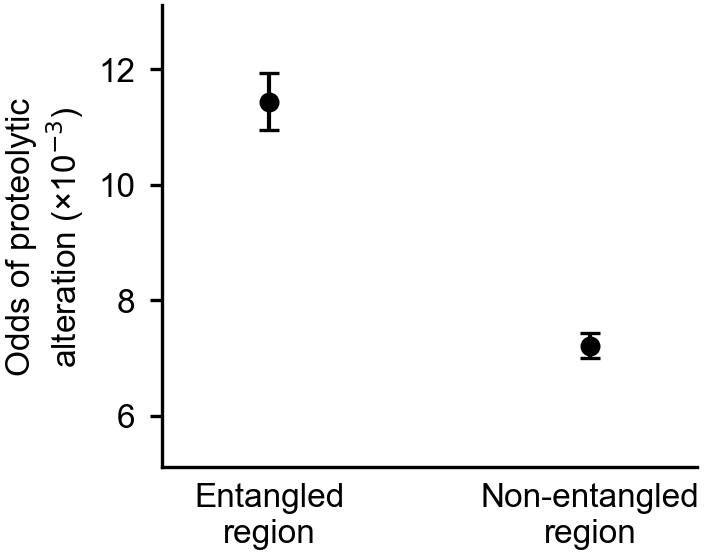

In [17]:
data = {
            "Entangled": [E_odds, E_ci_lower, E_ci_upper],
            "Non-entangled": [NE_odds, NE_ci_lower, NE_ci_upper]
        }
# The values in this analysis is too small so value display will be scaled by 1000 and clearly indicated in ylabel
data_scaled = {
    k: [v[0] * 1e3, v[1] * 1e3, v[2] * 1e3]
    for k, v in data.items()
}

fig_odds, ax_odds = plot_odds(
    data=data_scaled,
    xlabel="",
    ylabel="Odds of proteolytic\nalteration (×10$^{-3}$)",
    figsize=(2.30, 2.00),
    yticks=np.arange(0, 14, 2),
    xlim=(0.5, 1.5),
    ylim=(5.1, 13.1),
    xtick_labels=['Entangled\nregion', 'Non-entangled\nregion'],
    positions = [0.7, 1.3]
)

plt.show()
fig_odds.savefig('figs/Residue_Level_LR_odds.pdf')
fig_odds.savefig('figs/Residue_Level_LR_odds.png', dpi=300)

In [18]:
RUN_END = datetime.now().astimezone()

print("\n" + "=" * 50)
print("RUN END")
print("=" * 50)
print(f"{'date':12s}: {RUN_END.strftime('%Y-%m-%d')}")
print(f"{'time':12s}: {RUN_END.strftime('%H:%M:%S %Z')}")
print(f"{'iso':12s}: {RUN_END.isoformat()}")

# Duration
duration = RUN_END - RUN_START
print(f"{'duration':12s}: {str(duration).split('.')[0]}")  # remove microseconds

print("=" * 50)


RUN END
date        : 2026-03-31
time        : 14:02:16 +07
iso         : 2026-03-31T14:02:16.874931+07:00
duration    : 0:00:06
